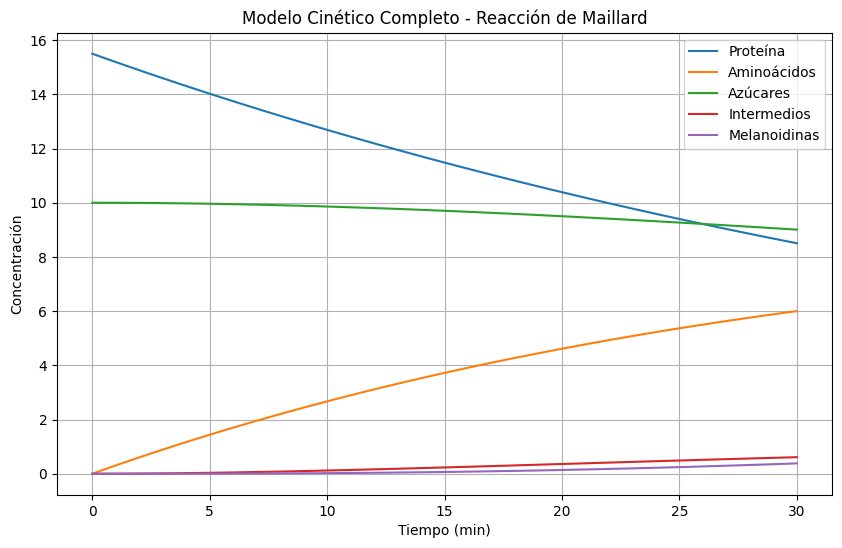

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Sistema de ecuaciones diferenciales
def modelo_maillard(y, t, k1, k2, k3):
    P, A, S, I, M = y

    dPdt = -k1 * P
    dAdt = k1 * P - k2 * A * S
    dSdt = -k2 * A * S
    dIdt = k2 * A * S - k3 * I
    dMdt = k3 * I

    return [dPdt, dAdt, dSdt, dIdt, dMdt]

# Condiciones iniciales
P0 = 15.5   # proteína inicial
A0 = 0.0    # aminoácidos
S0 = 10.0   # azúcares
I0 = 0.0
M0 = 0.0

y0 = [P0, A0, S0, I0, M0]

# Constantes cinéticas (ejemplo)
k1 = 0.02
k2 = 0.001
k3 = 0.05

# Tiempo
t = np.linspace(0, 30, 100)

# Solución
sol = odeint(modelo_maillard, y0, t, args=(k1, k2, k3))

P, A, S, I, M = sol.T

# Gráfica
plt.figure(figsize=(10,6))
plt.plot(t, P, label='Proteína')
plt.plot(t, A, label='Aminoácidos')
plt.plot(t, S, label='Azúcares')
plt.plot(t, I, label='Intermedios')
plt.plot(t, M, label='Melanoidinas')

plt.xlabel('Tiempo (min)')
plt.ylabel('Concentración')
plt.title('Modelo Cinético Completo - Reacción de Maillard')
plt.legend()
plt.grid()
plt.show()


===== Parámetros ajustados =====
k1 = 0.009875
k2 = 0.000000
k3 = 1.594500
k4 = 0.509478

===== Punto óptimo de aroma =====
Tiempo óptimo ≈ 6.82 min
2-AP máximo ≈ 0.15 (aroma frutal/floral)


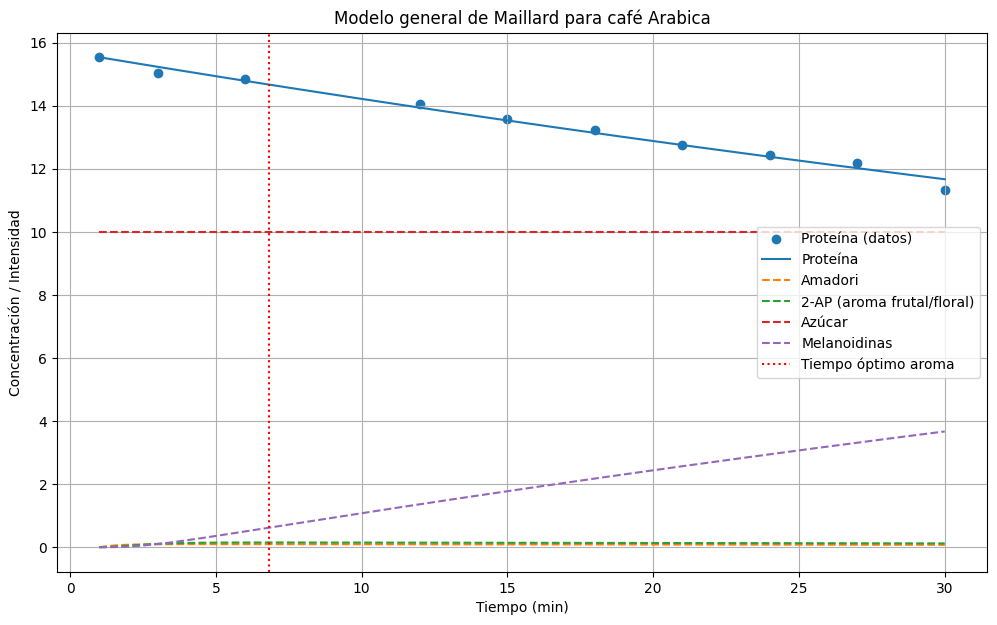

In [14]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# ==============================
# 1. Datos experimentales (proteína)
# ==============================
tiempos = np.array([1, 3, 6, 12, 15, 18, 21, 24, 27, 30])  # minutos
P_exp = np.array([15.54, 15.04, 14.86, 14.06, 13.59, 13.24, 12.76, 12.43, 12.19, 11.32])

# ==============================
# 2. Parámetros generales
# ==============================
humedad = 0.10         # Humedad inicial típica Arabica
factor_amino = 0.8     # Disponibilidad de aminoácidos

def factor_humedad(h):
    return 1 - 0.5 * h

fh = factor_humedad(humedad)

# ==============================
# 3. Modelo de Maillard (general)
# ==============================
def modelo_maillard_general(y, t, k1, k2, k3, k4):
    P, A, AP, S, M = y

    # Constantes efectivas
    k2_eff = k2 * fh * factor_amino
    k3_eff = k3 * fh
    k4_eff = k4 * (1 + (1 - humedad))

    # Ecuaciones diferenciales
    dPdt = -k1 * P - k2_eff * P * S
    dAdt = k1 * P + k2_eff * P * S - k3_eff * A
    dAPdt = k3_eff * A - k4_eff * AP   # 2-AP: aroma frutal/floral
    dSdt = -k2_eff * P * S
    dMdt = k4_eff * AP                 # Melanoidinas: color tostado

    return [dPdt, dAdt, dAPdt, dSdt, dMdt]

# ==============================
# 4. Función para ajuste
# ==============================
def modelo_para_fit(t, k1, k2, k3, k4):
    y0 = [P_exp[0], 0.0, 0.0, 10.0, 0.0]
    sol = odeint(modelo_maillard_general, y0, t, args=(k1, k2, k3, k4))
    return sol[:, 0]  # Ajuste solo proteína

# ==============================
# 5. Ajuste de parámetros
# ==============================
popt, pcov = curve_fit(
    modelo_para_fit,
    tiempos,
    P_exp,
    p0=[0.0215, 0.00112, 0.0583, 0.0247],
    bounds=(0, np.inf),
    maxfev=20000
)

k1_opt, k2_opt, k3_opt, k4_opt = popt

print("\n===== Parámetros ajustados =====")
print(f"k1 = {k1_opt:.6f}")
print(f"k2 = {k2_opt:.6f}")
print(f"k3 = {k3_opt:.6f}")
print(f"k4 = {k4_opt:.6f}")

# ==============================
# 6. Simulación general
# ==============================
t_sim = np.linspace(1, 30, 300)
y0 = [P_exp[0], 0.0, 0.0, 10.0, 0.0]
sol = odeint(modelo_maillard_general, y0, t_sim, args=(k1_opt, k2_opt, k3_opt, k4_opt))
P_sim, A_sim, AP_sim, S_sim, M_sim = sol.T

# ==============================
# 7. Punto óptimo de aroma (2-AP)
# ==============================
indice_max = np.argmax(AP_sim)
tiempo_opt = t_sim[indice_max]
AP_max = AP_sim[indice_max]

print("\n===== Punto óptimo de aroma =====")
print(f"Tiempo óptimo ≈ {tiempo_opt:.2f} min")
print(f"2-AP máximo ≈ {AP_max:.2f} (aroma frutal/floral)")

# ==============================
# 8. Gráficas generales
# ==============================
plt.figure(figsize=(12,7))
plt.scatter(tiempos, P_exp, label='Proteína (datos)')
plt.plot(t_sim, P_sim, label='Proteína')
plt.plot(t_sim, A_sim, '--', label='Amadori')
plt.plot(t_sim, AP_sim, '--', label='2-AP (aroma frutal/floral)')
plt.plot(t_sim, S_sim, '--', label='Azúcar')
plt.plot(t_sim, M_sim, '--', label='Melanoidinas')
plt.axvline(tiempo_opt, linestyle=':', color='red', label='Tiempo óptimo aroma')
plt.title('Modelo general de Maillard para café Arabica')
plt.xlabel('Tiempo (min)')
plt.ylabel('Concentración / Intensidad')
plt.legend()
plt.grid()
plt.show()